### Offshore DAS

In [26]:
import sys
import numpy as np
from pathlib import Path

sys.path.append('..')

from src.plot import plot_das_wavefield, plot_das_psd, plot_das_psd_2d

In [27]:
# 1. Define paths 
offshore_dir = Path('..') / 'data' / 'raw_offshore'

# Grab the first processed offshore files
offshore_files = sorted(offshore_dir.glob('*_offshore.npz'))
das_paths = offshore_files[:1]

if not das_paths:
    raise FileNotFoundError(f"No _offshore.npz files found in {offshore_dir}")

for p in das_paths:
    print(f"Found: {p.name}")

Found: 20180819_win0000_offshore.npz


In [28]:
# 2. Load the first file
das_data = np.load(das_paths[0])

print("\nKeys inside .npz file:")
for key in das_data:
    print(f' - {key}')


Keys inside .npz file:
 - data
 - dt
 - start_sample
 - end_sample


In [29]:
# 3. Extract data and natively saved metadata
raw_array = das_data['data']
dt = float(das_data['dt'])           
dx = 10           
fs = 1.0 / dt

N = raw_array.shape[1]               # Number of time samples
num_channels = raw_array.shape[0]    # Number of channels

In [30]:
# 4. PREPROCESSING: Zero-mean the data (DC Offset Removal)
das_array = raw_array - np.mean(raw_array, axis=1, keepdims=True)

# 5. Create t_axis and x_axis ON THE FLY
t_axis = np.arange(N) * dt              
x_axis = np.arange(num_channels) * dx  

print(f"\nDAS array shape: {das_array.shape} (Channels x Time)")
print(f"Time axis shape: {t_axis.shape}")
print(f"Channel axis shape: {x_axis.shape}")
print(f"Total duration: {(N * dt) / 60:.2f} minutes")
print(f"Total bridge length: {x_axis[-1]:.2f} meters")


DAS array shape: (3192, 2048) (Channels x Time)
Time axis shape: (2048,)
Channel axis shape: (3192,)
Total duration: 3.41 minutes
Total bridge length: 31910.00 meters


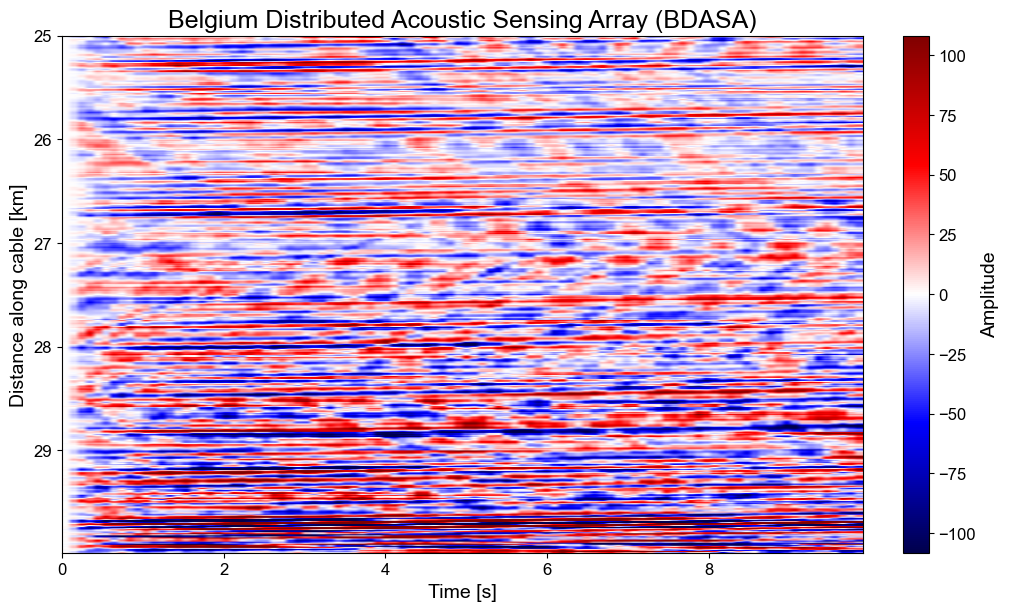

In [31]:
plot_das_wavefield(
    das_array,
    fs=fs,
    dx=dx,
    start_sec=0.0,
    duration_sec=10.0,     
    start_chan=2500, 
    end_chan=3000, 
    pclip=98,            
    title="Belgium Distributed Acoustic Sensing Array (BDASA)", 
    figsize=(10, 6)
)

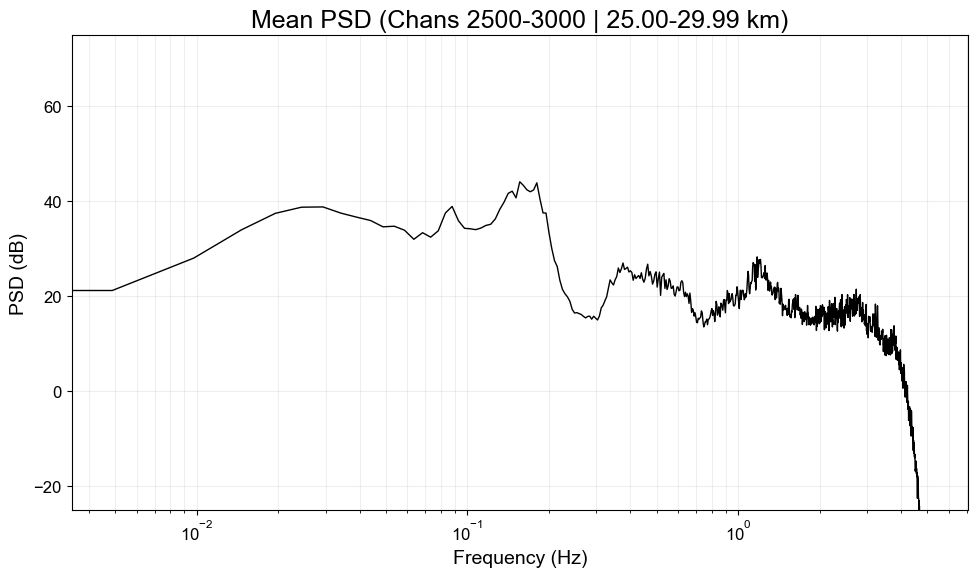

In [32]:
plot_das_psd(
    data=das_array,
    fs=fs,
    dx=dx,
    start_chan=2500,
    end_chan=3000,
    nperseg=2048,            
    xlim=None,       
    ylim=(-25, 75),              
    xscale="log",         
    ylabel="PSD (dB)",
    figsize=(10, 6), 
)

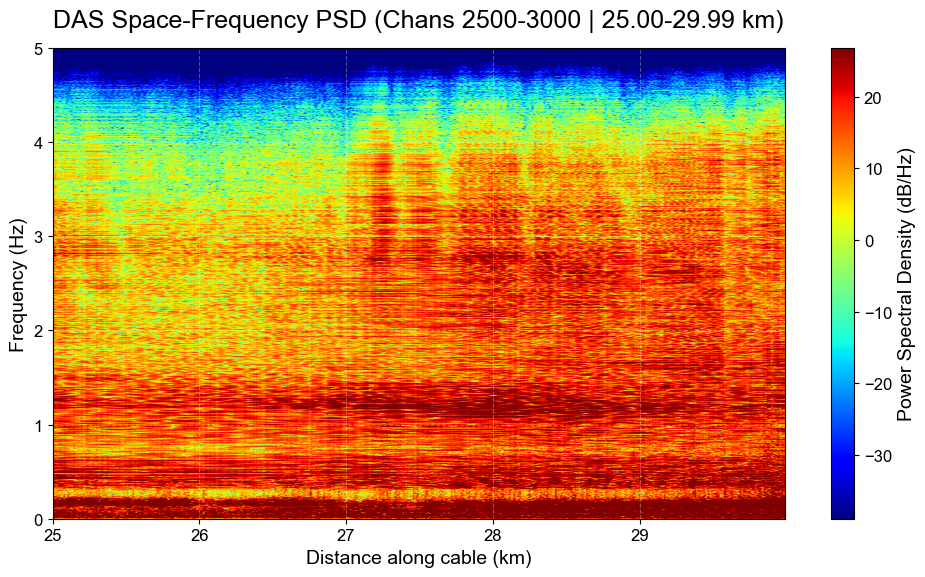

In [33]:
plot_das_psd_2d(
    data=das_array,
    fs=fs,
    dx=dx,
    start_chan=2500,
    end_chan=3000,
    nperseg=2048,     
    flim=(0, 5),                            
    figsize=(10, 6)
)